# Notebook 16: Displaying Correlation and Probability Matrices

# 1) Correlation Matrices from the Soccer Database

Let's first read in the same European Soccer database that we used to learn linear regression in Notebook 14.

As a reminder, this <a href="https://www.kaggle.com/hugomathien/soccer">European Soccer Database</a> has data on more than 25,000 matches and more than 10,000 players for European professional soccer seasons from 2008 to 2016.


### Import Libraries<br>


In [53]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read Data from the SQL Database into pandas
<br>


In [54]:
# Create your SQL connection.
from google.colab import drive
drive.mount ('/content/drive')
cnx = sqlite3.connect('drive/My Drive/Notebook16/database.sqlite')
df = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)
#This should read in the player data from the database.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
#Lets inspect this dataframe first.
df.shape

(183978, 42)

In [56]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='object')

So it looks like there are 183,978 player ratings ("overall_rating"), along with a bunch of other measurements of their relevant soccer skills such as "sprint_speed", shot_power", etc.

In [57]:
pd.set_option("display.max_columns", None) #This is so we can see all columns.
df.head()
#We will not want to include things like "attacking_work_rate" for example that are not numerical values.

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0



### Declare the Columns We Want to Use
<br>
We will use the following 25 columns of the DataFrame to produce an easily readable plot. Note that this is a little fewer than the 34 columns that we used in the linear regression analysis in Notebook 14.

In [58]:
features = ['overall_rating','crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision']

In [59]:
#Drop rows with NaNs, and then determine how many were dropped.
dfclean = df.dropna()
print (round(((df.shape[0]-dfclean.shape[0])/df.shape[0] * 100.0),2), "percent of the rows were dropped.")

1.97 percent of the rows were dropped.


In [60]:
#Select our 25 features.
dfclean_feat = dfclean[features]

Now we will calculate all possible correlation coefficients among these features using the DataFrame.corr() method. Since there are 25 features, this will produce 25\*\*2 values arranged in a square matrix. The diagonal entries will all be exactly 1, since the correlation coefficient of any variable with itself is 1.

We can then display this square matrix as an "image". The seaborn package provides a nice routine for this; seaborn is another python grpahics package that caters more toward professional looking graphics than does matplotlib. Here we will use the seaborn routine "heatmap" to display the image. Unlike plt.imshow that we have used previously, it will label the axis value, and plot an automatic colorbar, both of which are very useful in this case.

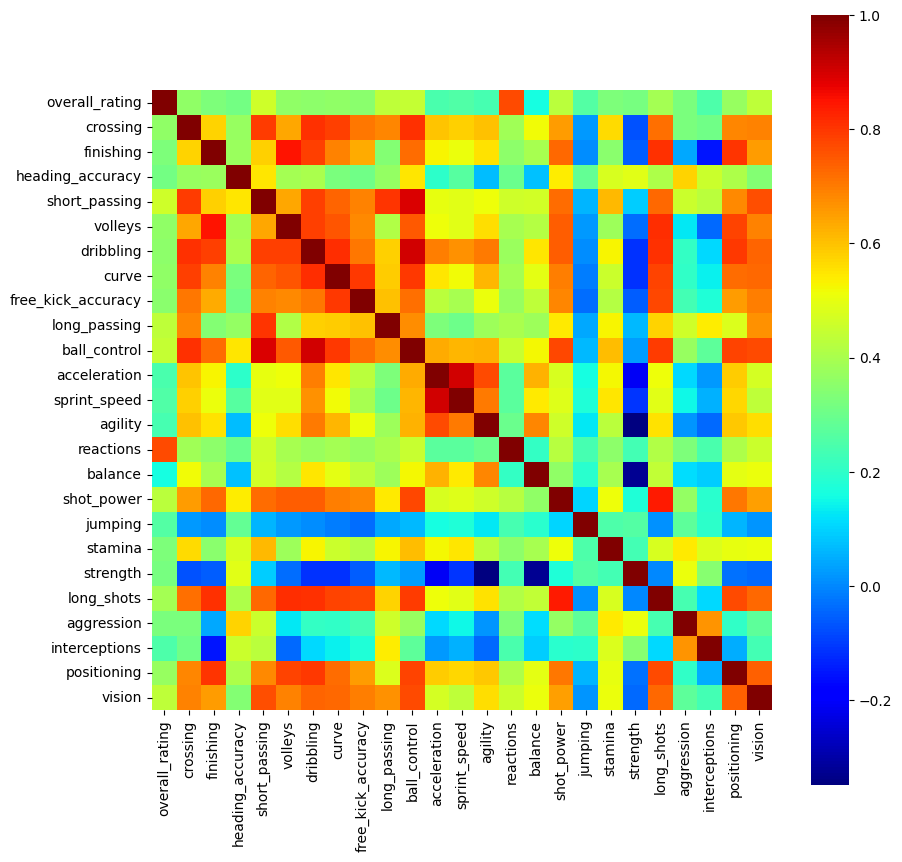

In [61]:
#calculate and display the correlation coefficients.
corr = dfclean_feat.corr()
plt.figure(figsize = (10,10))
sns.heatmap(corr,square=True,cmap='jet')
plt.show()

Note that positive values here means that the features are directly related, while negative values means that the features are **inversely** related.

### Finding what influences overall_rating:
Let's figure out the three quantities that correlate most strongly with overall_rating. We can then compare that list with the similar list we got in Notebook 14 of the three features that had the highest slopes in our linear regression fit to overall_rating. The two lists should be very similar, they are both ways of detecting which features strongly influence overall_rating.

In [62]:
#This finds the numbers of the features that produce the second, third, and fourth highest correlation coefficients
#with overall_rating. Note that we do not want the first highest, because that will just be the correlation of
#overall_rating with itself, which is 1.
np.argsort(corr['overall_rating'].to_numpy())[-4:-1]

array([10,  4, 14])

In [63]:
#This identifies the names of the three feature numbers that we just found above.
corrlist=[corr.index[i] for i in np.argsort(corr['overall_rating'].to_numpy())[-4:-1]]
corrlist

['ball_control', 'short_passing', 'reactions']

The result above makes sense. We previously identified 'ball_control' and 'reactions' in Notebook 14. The third feature that we found in Notebook 14, 'gk_diving', was not included in the feature list this time, so 'short_passing' takes its place.

### Finding the strongest negative correlation in the entire matrix:

Now let's look for the strongest negative correlation in the matrix (the two quantities that are most oppositely related). We will use argmin to return the index of the minimum value. One complication is that we are searching the whole two-dimensional array, but argmin will return only a single index, the count through all of the array elements. We use the new command [np.unravel_index](https://numpy.org/doc/stable/reference/generated/numpy.unravel_index.html) to cast this back into two-dimensional form so that we can index with it.

In [64]:
minlist=[corr.index[i] for i in np.unravel_index(corr.to_numpy().argmin(),corr.shape)]
minlist

['agility', 'strength']

Nice, this confirms the common-sense notion that 'strength' and 'agility' are inversely related.

### Finding the strongest positive correlation in the entire matrix:
Now let's do the same thing, but to find the strongest positive correlation. One complication now is that we need to ignore all the 1's that are in the matrix from the correlation of each feature with itself. Below we first set all the 1's to -1's, then find the maximum, then change all the -1's back to 1's again.

In [65]:
corr[corr==1]=-1

In [66]:
maxlist=[corr.index[i] for i in np.unravel_index(corr.to_numpy().argmax(),corr.shape)]
maxlist

['acceleration', 'sprint_speed']

In [67]:
corr[corr==-1]=1

We find the two most strongly related features are 'acceleration' and 'sprint_speed'. Again, this checks with our common senese, a more powerful acceleration results in a higher speed, from fundamental physics.


# 2) Correlation Matrices from the Automotive Database

Now you will practice using some of these routines on the automotive databse that we used to learn pivot tables back in Notebook 9. As a reminder, this database on automobiles gives 25 different properties of 205 different cars, from 1985. This database in publicly available through the sklearns.datasets package.

In [68]:
from sklearn.datasets import fetch_openml
X,y = fetch_openml("autos", version=1, as_frame=True, return_X_y=True, parser='auto')
df = X

In [69]:
#Drop rows with NaNs, and then determine how many were dropped.
dfclean=df.dropna()
dfclean

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
6,158.0,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
8,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
10,192.0,bmw,gas,std,two,sedan,rwd,front,101.2,176.8,64.8,54.3,2395,ohc,four,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29,16430.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [70]:
print (round(((df.shape[0]-dfclean.shape[0])/df.shape[0] * 100.0),2), "percent of the rows were dropped.")

22.44 percent of the rows were dropped.


### Declare the Columns We Want to Use:
We need to select features to use. Once again, to compute correlation coefficients we need **numerical** data.
We select the following 14 features, which, upon inspection of the DataFrame above, all contain numerical data.

In [71]:
features = ['price','wheel-base','length','width','height','curb-weight','engine-size',
            'bore','stroke','compression-ratio','horsepower','peak-rpm',
            'city-mpg','highway-mpg']
dfclean_feat = dfclean[features]

## Excercise 1: Calculate and display the correlation coefficeints:

Calculate the correlation coefficeint matrix for the dfclean_feat DataFrame. Then display it using the sns.heatmap routine. Since this matrix is smaller than the soccer one, we can print the correlation coefficients directly on the display. You can do this by passing the "annot=True" option to sns.heatmap. Your answer should look like the file answer1.pdf included with this notebook.

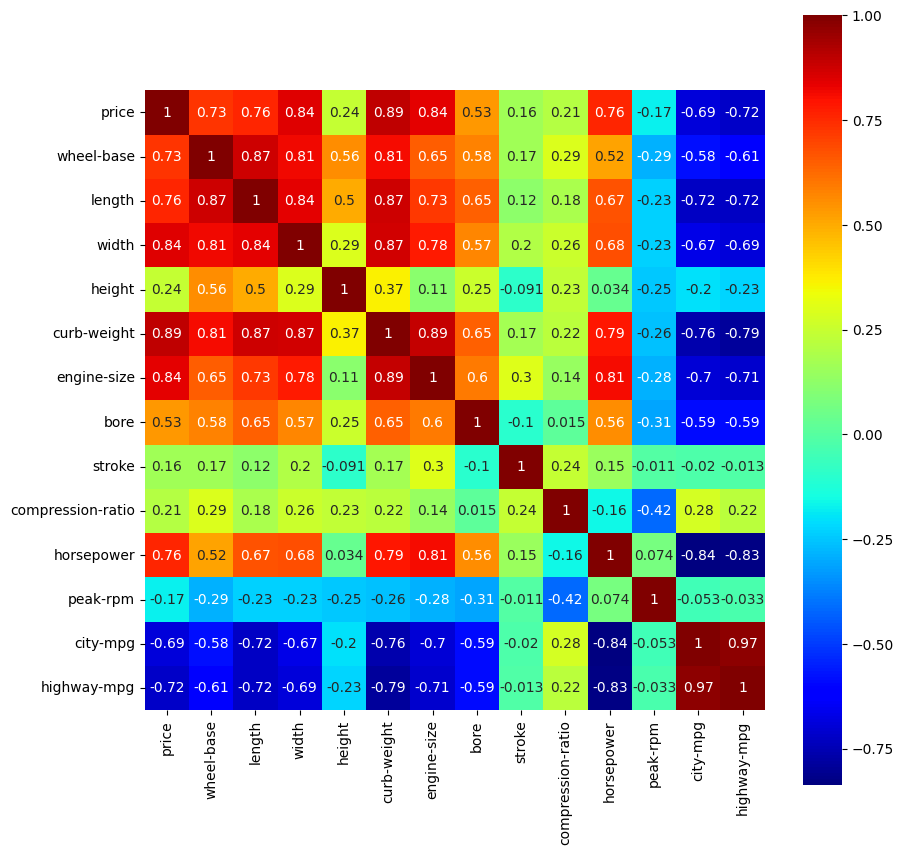

In [72]:
### YOUR CODE HERE!
### YOUR PLOT HERE!
corr = dfclean_feat.corr()
plt.figure(figsize = (10,10))
sns.heatmap(corr,square=True,cmap='jet',annot=True)
plt.show()


## Excercise 2: Finding what influences price:
Following the example from the soccer database above, identify and print out the three features that are most strongly correlated with the 'price' of a car. You should find them to be \['engine-size', 'width', 'curb-weight'\] (bigger cars with bigger engines are more expensive).

In [73]:
### YOUR CODE HERE!
#This finds the numbers of the features that produce the second, third, and fourth highest correlation coefficients/price
np.argsort(corr['price'].to_numpy())[-4:-1]

array([6, 3, 5])

In [74]:
corrlist=[corr.index[i] for i in np.argsort(corr['price'].to_numpy())[-4:-1]]
corrlist

['engine-size', 'width', 'curb-weight']

## Exercise 3: Finding the strongest negative correlation in the entire matrix:
Following the example from the soccer database above, identify and print out the two features in the database that are most strongly negatively correlated with each other. You should find them to be \['horsepower', 'city-mpg'\], which again makes sense, more powerful cars get worse mileage.

In [75]:
### YOUR CODE HERE!
minlist=[corr.index[i] for i in np.unravel_index(corr.to_numpy().argmin(),corr.shape)]
minlist

['horsepower', 'city-mpg']

## Exercise 4: Finding the strongest positive correlation in the entire matrix:
Following the example from the soccer database above, identify and print out the two features in the database that are most strongly positively correlated with each other. You should find them to be \['city-mpg', 'highway-mpg'\]. Again this makes sense, high mileage cars get good mileage everywhere.

In [76]:
### YOUR CODE HERE!
corr[corr==1]=-1
maxlist=[corr.index[i] for i in np.unravel_index(corr.to_numpy().argmax(),corr.shape)]
maxlist

['city-mpg', 'highway-mpg']

In [77]:
corr[corr==-1]=1

# 3) Probabbility Matrices from the Movies Database:
We can do similar types of relational anayses with the movies database from Notebooks 7 and 8. However, in this case there are not multiple numerical measurements of each movie, so trying to compute a correlation coefficient matrix would not be useful. Instead, let us try to find relationships among movie genres. What we would like to compute is the following: Given that a movie belongs to 'Genre X', what is the probability that it **also** belongs to 'Genre Y'? (remember that movies are assigned multiple genres in this database). For example: Given that a movie has genre 'Animation', what is the probability that is also has genre 'Children'? This should produce a square matrix consisting of numbers between 0 and 1 that we can display with sns.heatmap, and that tells us about the relationship among genres.

In [78]:
#Read in the movies dataframe.
movies = pd.read_csv('drive/My Drive/Notebook16/movies.csv')
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


In [79]:
#Get an array of all of the genres. The .explode method joins all the arrays together into one big array,
#and .unique selects the unique elements of that big array.
allGenres=movies.genres.str.split('|').explode().unique()
allGenres

array(['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Mystery', 'Sci-Fi', 'IMAX', 'Documentary', 'War', 'Musical',
       'Western', 'Film-Noir', '(no genres listed)'], dtype=object)

In [80]:
#We make new columns, one for each genre. The movie gets a one if it belongs to that genre,
#it gets a zero if it doesn't.
for genre in allGenres:
    movies[genre]=[1 if genre in moviegenres else 0 for moviegenres in movies.genres]
movies.head()

,movieId,title,genres,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [81]:
#We define a new DataFrame that will hold our probabbility matrix.
genreRelation=pd.DataFrame(index=allGenres)

In [82]:
for genre in allGenres:
    genredf = movies[movies[genre]==1] #We first select just the 'Adventure' movies, for example.
    total_in_genre = genredf.shape[0] #We then compute the total number of 'Adventure' movies, for example.
    #The line below if the key line. It computes the total number of 'Adventure' movies that are also
    #'Animation' movies (for example), and then divides by the total number of 'Adventure' movies,
    #yielding a probability.
    genreRelation[genre]=genredf[allGenres].sum(axis=0)/total_in_genre

In [83]:
#The way we computed the matrix above it would have to be read by column. We now "tranpose" it,
#(swap rows and columns), so that it can be read by row, which is the more natural way.
genreRelation_byrows=genreRelation.transpose()

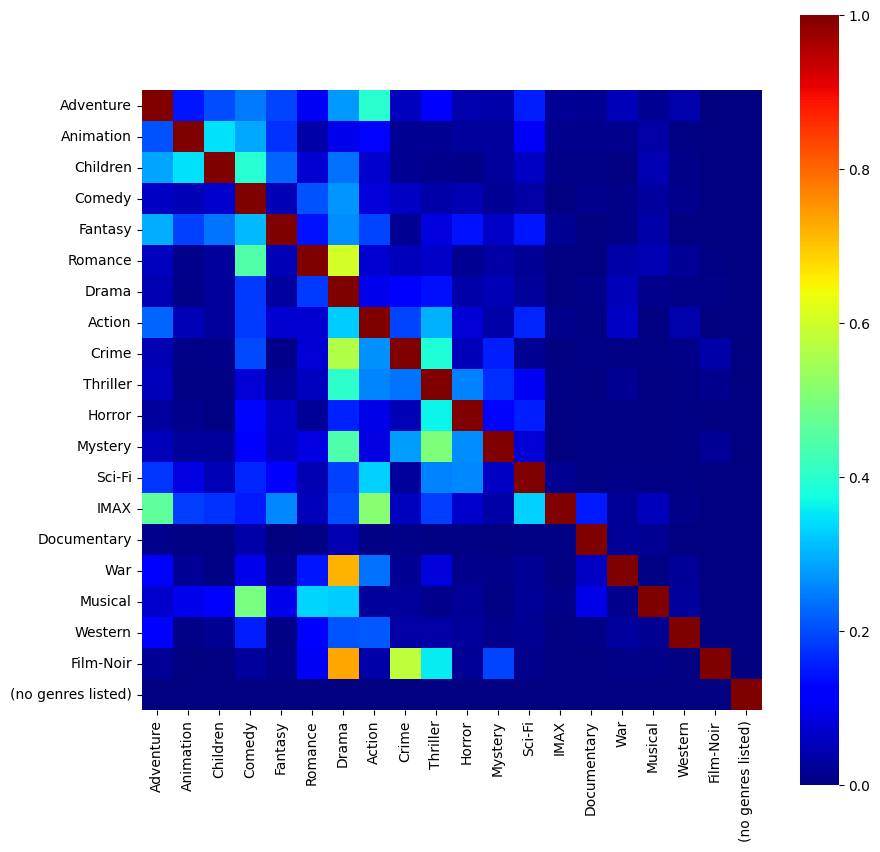

In [84]:
plt.figure(figsize = (10,10))
sns.heatmap(genreRelation_byrows,square=True,cmap='jet')
plt.show()

## Exercise 5: Reading the genre relations matrix:
Answer the following two questions based on the genre relation matrix plotted above. There is NO CODE REQUIRED here, it is just inspecting and reading the plot.<br>
1) If a movie has genre "Horror", what is the most likely other genre for it?<br>
2) If a movie has genre "War", what is the most liekly other genre for it?<br>

### Put your answers to Exercise 5 here!<br>
1: Thriller <br>
2: Drama

## A Genre Count Probability Matrix:
We want to compute and display one final matrix. It will have the genres down the rows, and the columns labeled with the numbers from 1 to 10. An entry at row X, column Y, should tell us the following: **"Given that a movie belongs to Genre X, what is the probability that it belongs to exactly Y genres?"**. Note that a movie with a genre must belong to a minimum of one genre (itself), and that no movie in the database has more than 10 genres assigned.

In [85]:
#Let's first assign a new DataFrame that contains only the ones and zeros based on genre identifications,
#selected from the modified movies DataFrame above.
onlygenres=movies[allGenres]
onlygenres.head()

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [86]:
#Create a blank DataFrame to hold the answer.
genrenumbers=pd.DataFrame(index=np.arange(10)+1)

In [87]:
for genre in allGenres:
    genredf = onlygenres[onlygenres[genre]==1]
    total_in_genre = genredf.shape[0]
    #This is similar to what we did before, but now we sum along ROWS to count total number of genres,
    #count how many of each total using .value_counts, and then arrange by index using .sort_index().
    genrenumbers[genre]=(genredf.sum(axis=1)).value_counts().sort_index()/total_in_genre

In [88]:
genrenumbers.head()

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
1,0.058625,0.248890,0.056899,0.336337,0.036250,0.036015,0.353667,0.076483,0.040985,0.106194,0.277342,0.044444,0.104033,0.005128,0.844068,0.047492,0.061670,0.400286,0.036827,1.0
2,0.228227,0.273814,0.382283,0.379846,0.238008,0.517295,0.358275,0.307975,0.332769,0.343656,0.358658,0.238974,0.321836,0.153846,0.126137,0.488260,0.370968,0.308077,0.203966,NaN
3,0.391797,0.262206,0.335945,0.204683,0.398755,0.330872,0.212411,0.384322,0.412672,0.357176,0.249958,0.417778,0.337135,0.153846,0.024621,0.326574,0.375712,0.186562,0.467422,NaN
4,0.212063,0.133493,0.146508,0.056254,0.216404,0.082912,0.057799,0.170114,0.162249,0.146869,0.088329,0.218462,0.167177,0.420513,0.004282,0.105123,0.125237,0.080057,0.215297,NaN
5,0.084198,0.061113,0.058944,0.017190,0.082754,0.026299,0.014684,0.047632,0.042865,0.037902,0.021539,0.064957,0.053129,0.179487,0.000535,0.024546,0.048387,0.021444,0.065156,NaN


## Exercise 6: Prepare the genre count matrix for plotting, and plot it.
The DataFrame above is almost what we want, but we need to do two things. First, we need to swap the rows and columns ("transpose" it, using the .transpose() method) to answer the original statement of the problem above. Second, the counting above returned some NaNs where there were no entries. Those need to be replaced by zeros before it will display properly. This can be done by using .fillna(0). Perform these two operations, and then plot the resulting matrix using sns.heatmap. Your answer should look like the file answer6.pdf included with this notebook.

In [ ]:
### YOUR CODE HERE!

### YOUR PLOT HERE!

In [89]:
#tranpose: swap rows and columns:
genrenumbers=genrenumbers.transpose()

In [90]:
genrenumbers.head()

,1,2,3,4,5,6,7,8,9,10
Adventure,0.058625,0.228227,0.391797,0.212063,0.084198,0.020507,0.003860,0.000483,NaN,0.000241
Animation,0.248890,0.273814,0.262206,0.133493,0.061113,0.016729,0.003414,0.000341,NaN,NaN
Children,0.056899,0.382283,0.335945,0.146508,0.058944,0.016695,0.002385,0.000341,NaN,NaN
Comedy,0.336337,0.379846,0.204683,0.056254,0.017190,0.004624,0.000889,0.000119,NaN,0.000059
Fantasy,0.036250,0.238008,0.398755,0.216404,0.082754,0.022336,0.004760,0.000732,NaN,NaN


In [92]:
#fill nans with 0's
genrenumbers=genrenumbers.fillna(0)

In [95]:
genrenumbers

,1,2,3,4,5,6,7,8,9,10
Adventure,0.058625,0.228227,0.391797,0.212063,0.084198,0.020507,0.003860,0.000483,0.0,0.000241
Animation,0.248890,0.273814,0.262206,0.133493,0.061113,0.016729,0.003414,0.000341,0.0,0.000000
Children,0.056899,0.382283,0.335945,0.146508,0.058944,0.016695,0.002385,0.000341,0.0,0.000000
Comedy,0.336337,0.379846,0.204683,0.056254,0.017190,0.004624,0.000889,0.000119,0.0,0.000059
Fantasy,0.036250,0.238008,0.398755,0.216404,0.082754,0.022336,0.004760,0.000732,0.0,0.000000
Romance,0.036015,0.517295,0.330872,0.082912,0.026299,0.004664,0.001814,0.000130,0.0,0.000000
Drama,0.353667,0.358275,0.212411,0.057799,0.014684,0.002343,0.000703,0.000078,0.0,0.000039
Action,0.076483,0.307975,0.384322,0.170114,0.047632,0.011159,0.002177,0.000000,0.0,0.000136
Crime,0.040985,0.332769,0.412672,0.162249,0.042865,0.006580,0.001504,0.000188,0.0,0.000188
Thriller,0.106194,0.343656,0.357176,0.146869,0.037902,0.006587,0.001387,0.000116,0.0,0.000116


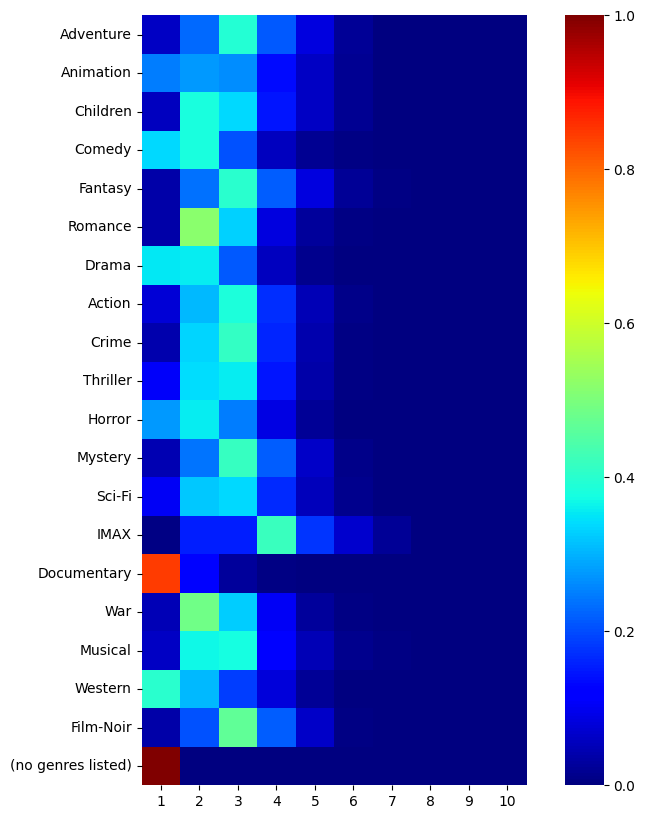

In [99]:
#plot
plt.figure(figsize = (10,10))
sns.heatmap(genrenumbers,square=True,cmap='jet')
plt.show()

So we find that the genre of movie with the **lowest** probability of belonging to any other genres is 'Documentary', and we find that the genre of movie with the **highest** probability of belonging to four or more genres is 'IMAX'.

In [102]:
# plt.figure(figsize = (10,10))
# sns.heatmap(genrenumbers,square=True,cmap='jet',annot=True)
# plt.show()